# Analyse XAI par dimension — modèle `small2_30ig` (≈200 dims)

Ce notebook prolonge `ig_dim_analysis.ipynb` mais sur le modèle **`small2_30ig`** :
le modèle small2 réentraîné après sélection des dimensions à 30 % d'IG cumulé.

Objectifs :
1. **IG signé** ciblant la classe *infection* (1) → identifier les dimensions
   qui *poussent* le modèle vers une prédiction positive (côté bactérie et phage).
2. **Remonter à l'ADN** pour ces dimensions « pro-infection » :
   corrélations entre la valeur de la dim et des features ADN simples
   (longueur, % GC, k-mers) sur les couples prédits positifs.


In [1]:
%cd ..
!pwd

/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code
/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code


/home/nathan/anaconda3/envs/pbi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from captum.attr import IntegratedGradients

from pbi_utils.data_manager import H5pyEmbeddingsManager, PerphectDataInput
from main import parse_config, reduce_dimensionality, test_model, make_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

Device : cuda


## 1. Chargement du modèle `small2_30ig`

On part de la config `small2`, on charge le dataset de test (`predphi_test`),
puis on *slice* les embeddings aux dimensions retenues (`ig30/bact_dims.npy`,
`ig30/phage_dims.npy`) et on charge les poids `ig30/trained_model.pth`.


In [3]:
config = parse_config(config_path="output/pbip/small2/training_config.yaml")

# Test set
config.input_perphect.couples_df = "data/perphect-data/predphi/predphi_test_dataset.csv"

output_manager = H5pyEmbeddingsManager(config.embeddings_dir)
bacteria_df, phages_df, couples_df = PerphectDataInput(input_paths=config.input_perphect).load()

bact_names  = [x.name() for x in config.bacteria_embedding_models]
phage_names = [x.name() for x in config.phages_embedding_models]

dataset_full = make_dataset(couples_df, bact_names, phage_names, output_manager, device)
dataset_full = reduce_dimensionality(
    dataset_full,
    config.training_config.reduce_dimensionality,
    config.output_dir,
    config.training_config.n_components_bacteria,
    config.training_config.n_components_phages,
)
print(f"Dataset full : {len(dataset_full)} samples")
print(f"Dim bact (full)  : {len(dataset_full['bacterium_embedding'].iloc[0])}")
print(f"Dim phage (full) : {len(dataset_full['phage_embedding'].iloc[0])}")

[INFO] Configuration loaded from output/pbip/idk/training_config.yaml: Config(input_perphect=bacteria_df='data/perphect-data/predphi/bacteria_sequences.csv' phages_df='data/perphect-data/predphi/bacteriophages_sequences.csv' couples_df='data/perphect-data/predphi/predphi_train_dataset.csv', embeddings_dir=data/embeddings-pbip, num_gpu=1, gpu_id=0, training_config=TrainingConfig(do_train=True do_test=False epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 training_noise_std=0.05 stratify_cv=True k_folds_cv=1 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_factor_reduce_lr=0.5 reduce_dimensionality='none' n_components_bacteria=None n_components_phages=None), phages_embedding_models=[NT2(merging_strategy=TruncateStrategy(), overlap=0, model_name='nucleotide-transformer-v2-250m-multi-species')], compute_phages_embeddings=[True], bacteria_embedding_models=[MegaDNA(merging_strategy=TruncateStrat

Loading embeddings:   0%|          | 0/1236 [00:00<?, ?it/s]

[DEBUG] Loading 1236 embeddings for model NT2-TruncateStrategy-250M-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/1236 [00:00<?, ?it/s]

[DEBUG] Final embedding size (bacteria): 964
[DEBUG] Final embedding size (phages): 768
Dataset full : 1236 samples
Dim bact (full)  : 964
Dim phage (full) : 768


In [4]:
ig30_dir = os.path.join(config.output_dir, "ig30")
bact_dims_30  = np.load(os.path.join(ig30_dir, "bact_dims.npy"))
phage_dims_30 = np.load(os.path.join(ig30_dir, "phage_dims.npy"))

print(f"Dims retenues — bact : {len(bact_dims_30)} | phage : {len(phage_dims_30)} | total : {len(bact_dims_30)+len(phage_dims_30)}")


def select_dims_in_dataset(ds, bact_dims, phage_dims):
    ds2 = ds.copy()
    ds2["bacterium_embedding"] = [e[bact_dims].float()  for e in ds["bacterium_embedding"]]
    ds2["phage_embedding"]     = [e[phage_dims].float() for e in ds["phage_embedding"]]
    return ds2


dataset = select_dims_in_dataset(dataset_full, bact_dims_30, phage_dims_30)
bact_emb_size  = len(dataset["bacterium_embedding"].iloc[0])
phage_emb_size = len(dataset["phage_embedding"].iloc[0])
print(f"Dim bact (30ig)  : {bact_emb_size}")
print(f"Dim phage (30ig) : {phage_emb_size}")

Dims retenues — bact : 69 | phage : 125 | total : 194
Dim bact (30ig)  : 69
Dim phage (30ig) : 125


In [5]:
model = config.classifier(bact_emb_size, phage_emb_size, **config.classifier_params).to(device)
model.load_state_dict(torch.load(os.path.join(ig30_dir, "trained_model.pth"), map_location=device))
model.eval()

# Sanity check
test_model(dataset, model, batch_size=config.training_config.batch_size, device=device);

[INFO] Starting testing...
[INFO] Accuracy (test): 0.7742718458175659
[INFO] Recall (test): 0.7588996887207031
[INFO] F1 score (test): 0.770747721195221
[INFO] Loss (test): 0.5538340399951996
[INFO] Confusion Matrix (test) (TP, FP, FN, TN): (469, 130, 149, 488)


## 2. Prédictions + outcome par sample

In [6]:
model.eval()
preds, probs = [], []
with torch.no_grad():
    for _, row in dataset.iterrows():
        out = model(
            row["bacterium_embedding"].unsqueeze(0).to(device),
            row["phage_embedding"].unsqueeze(0).to(device),
        )
        p = torch.softmax(out, dim=1)[0]
        preds.append(int(p.argmax().item()))
        probs.append(float(p[1].item()))

dataset["prediction"]  = preds
dataset["probability"] = probs

def outcome(row):
    t, p = int(row["interaction_type"]), int(row["prediction"])
    return {(1,1):"TP", (0,0):"TN", (0,1):"FP", (1,0):"FN"}[(t, p)]

dataset["outcome"] = dataset.apply(outcome, axis=1)
print(dataset["outcome"].value_counts())

outcome
TN    488
TP    469
FN    149
FP    130
Name: count, dtype: int64


## 3. Baseline médiane pour IG

In [7]:
all_bact_embs  = torch.stack([t.detach().cpu() for t in dataset["bacterium_embedding"]])
all_phage_embs = torch.stack([t.detach().cpu() for t in dataset["phage_embedding"]])

median_bact  = torch.median(all_bact_embs,  dim=0).values.float().to(device)
median_phage = torch.median(all_phage_embs, dim=0).values.float().to(device)

del all_bact_embs, all_phage_embs
print("Baseline médiane calculée.")

Baseline médiane calculée.


## 4. Calcul IG ciblant la classe « infection » (1)

Contrairement à `ig_dim_analysis.ipynb` qui cible la classe 0, on cible ici la
classe **1** (infection) pour pouvoir distinguer les dims qui *augmentent* la
probabilité d'infection (IG signé > 0) de celles qui la diminuent (IG < 0).


In [8]:
def forward_prob_infection(bact_emb, phage_emb):
    """Retourne prob(classe 1 = infection), shape [B, 1]."""
    out = model(bact_emb, phage_emb)
    return torch.softmax(out, dim=1)[:, 1:2]


ig = IntegratedGradients(forward_prob_infection)

# Completeness check
row0 = dataset.iloc[0]
b0 = row0["bacterium_embedding"].to(device).unsqueeze(0)
p0 = row0["phage_embedding"].to(device).unsqueeze(0)

attr_b0, attr_p0 = ig.attribute(
    inputs=(b0, p0),
    baselines=(median_bact.unsqueeze(0), median_phage.unsqueeze(0)),
    target=0, n_steps=50,
)
with torch.no_grad():
    prob_x    = forward_prob_infection(b0, p0).item()
    prob_base = forward_prob_infection(median_bact.unsqueeze(0), median_phage.unsqueeze(0)).item()

ig_sum = attr_b0.sum().item() + attr_p0.sum().item()
delta  = prob_x - prob_base
print(f"Sum(IG)            : {ig_sum:.4f}")
print(f"prob(x) - prob(base): {delta:.4f}")
print(f"Erreur completeness : {abs(ig_sum - delta):.6f}")

Sum(IG)            : 0.2373
prob(x) - prob(base): 0.2330
Erreur completeness : 0.004309


In [9]:
N_STEPS = 50

ig_bact_raw  = np.zeros((len(dataset), bact_emb_size),  dtype=np.float32)
ig_phage_raw = np.zeros((len(dataset), phage_emb_size), dtype=np.float32)

model.eval()
for i, (_, row) in enumerate(tqdm(dataset.iterrows(), total=len(dataset), desc="IG")):
    b = row["bacterium_embedding"].clone().float().to(device).unsqueeze(0)
    p = row["phage_embedding"].clone().float().to(device).unsqueeze(0)
    attr_b, attr_p = ig.attribute(
        inputs=(b, p),
        baselines=(median_bact.unsqueeze(0), median_phage.unsqueeze(0)),
        target=0, n_steps=N_STEPS,
    )
    ig_bact_raw[i]  = attr_b.squeeze().cpu().numpy()
    ig_phage_raw[i] = attr_p.squeeze().cpu().numpy()

ig_bact_abs  = np.abs(ig_bact_raw)
ig_phage_abs = np.abs(ig_phage_raw)

print(f"ig_bact_raw  : {ig_bact_raw.shape}  (signed)")
print(f"ig_phage_raw : {ig_phage_raw.shape} (signed)")

IG: 100%|██████████| 1236/1236 [00:03<00:00, 311.51it/s]

ig_bact_raw  : (1236, 69)  (signed)
ig_phage_raw : (1236, 125) (signed)


## 5. Dimensions qui *poussent* vers une prédiction d'infection

On regarde l'IG **signé** moyen sur les samples prédits positifs (et idéalement
*vrais* positifs) : une dimension avec IG signé moyen fortement positif sur les
TP est une dimension dont la valeur observée pousse régulièrement le modèle
vers la classe 1.


In [10]:
idx_tp = dataset.index[dataset["outcome"] == "TP"].tolist()
idx_tn = dataset.index[dataset["outcome"] == "TN"].tolist()
idx_pos_pred = dataset.index[dataset["prediction"] == 1].tolist()

print(f"TP        : {len(idx_tp)}")
print(f"TN        : {len(idx_tn)}")
print(f"Prédits + : {len(idx_pos_pred)}")

# Pro-infection : IG signé moyen sur les TP (élevé = pousse vers classe 1 sur les vrais positifs)
mean_ig_bact_tp  = ig_bact_raw[idx_tp].mean(axis=0)
mean_ig_phage_tp = ig_phage_raw[idx_tp].mean(axis=0)

# Anti-infection : IG signé moyen sur les TN (très négatif = pousse vers classe 0 sur les vrais négatifs).
# On cible toujours la classe 1 dans IG, donc une dim avec IG_TN très négatif est une dim
# dont la valeur observée sur les TN abaisse prob(infection) → "anti-infection".
mean_ig_bact_tn  = ig_bact_raw[idx_tn].mean(axis=0)
mean_ig_phage_tn = ig_phage_raw[idx_tn].mean(axis=0)

# Importance absolue (référence)
mean_ig_bact_abs  = ig_bact_abs.mean(axis=0)
mean_ig_phage_abs = ig_phage_abs.mean(axis=0)

K = 20
top_bact_push  = np.argsort(mean_ig_bact_tp)[::-1][:K]   # IG_TP max  → pro-infection
top_phage_push = np.argsort(mean_ig_phage_tp)[::-1][:K]
top_bact_block  = np.argsort(mean_ig_bact_tn)[:K]        # IG_TN min  → anti-infection
top_phage_block = np.argsort(mean_ig_phage_tn)[:K]

print("\nTop-10 dims bact PRO-infection (IG signé moyen sur TP) :")
for d in top_bact_push[:10]:
    print(f"  dim {d:4d} (orig {bact_dims_30[d]:4d})  IG_TP={mean_ig_bact_tp[d]:+.4f}  |IG|={mean_ig_bact_abs[d]:.4f}")
print("\nTop-10 dims phage PRO-infection (IG signé moyen sur TP) :")
for d in top_phage_push[:10]:
    print(f"  dim {d:4d} (orig {phage_dims_30[d]:4d})  IG_TP={mean_ig_phage_tp[d]:+.4f}  |IG|={mean_ig_phage_abs[d]:.4f}")

print("\nTop-10 dims bact ANTI-infection (IG signé moyen sur TN) :")
for d in top_bact_block[:10]:
    print(f"  dim {d:4d} (orig {bact_dims_30[d]:4d})  IG_TN={mean_ig_bact_tn[d]:+.4f}  |IG|={mean_ig_bact_abs[d]:.4f}")
print("\nTop-10 dims phage ANTI-infection (IG signé moyen sur TN) :")
for d in top_phage_block[:10]:
    print(f"  dim {d:4d} (orig {phage_dims_30[d]:4d})  IG_TN={mean_ig_phage_tn[d]:+.4f}  |IG|={mean_ig_phage_abs[d]:.4f}")

TP        : 469
TN        : 488
Prédits + : 599

Top-10 dims bact PRO-infection (IG signé moyen sur TP) :
  dim   31 (orig  414)  IG_TP=+0.0527  |IG|=0.0896
  dim   33 (orig  420)  IG_TP=+0.0459  |IG|=0.0664
  dim   35 (orig  445)  IG_TP=+0.0417  |IG|=0.0904
  dim    1 (orig    7)  IG_TP=+0.0201  |IG|=0.0698
  dim   52 (orig  655)  IG_TP=+0.0133  |IG|=0.0377
  dim   25 (orig  309)  IG_TP=+0.0116  |IG|=0.0240
  dim   60 (orig  716)  IG_TP=+0.0098  |IG|=0.0201
  dim   48 (orig  636)  IG_TP=+0.0087  |IG|=0.0125
  dim   47 (orig  620)  IG_TP=+0.0087  |IG|=0.0129
  dim   19 (orig  246)  IG_TP=+0.0059  |IG|=0.0314

Top-10 dims phage PRO-infection (IG signé moyen sur TP) :
  dim  115 (orig  709)  IG_TP=+0.0329  |IG|=0.0348
  dim   87 (orig  541)  IG_TP=+0.0241  |IG|=0.0235
  dim  100 (orig  622)  IG_TP=+0.0206  |IG|=0.0305
  dim   90 (orig  553)  IG_TP=+0.0205  |IG|=0.0313
  dim   92 (orig  559)  IG_TP=+0.0193  |IG|=0.0325
  dim   44 (orig  283)  IG_TP=+0.0133  |IG|=0.0231
  dim   50 (orig  3

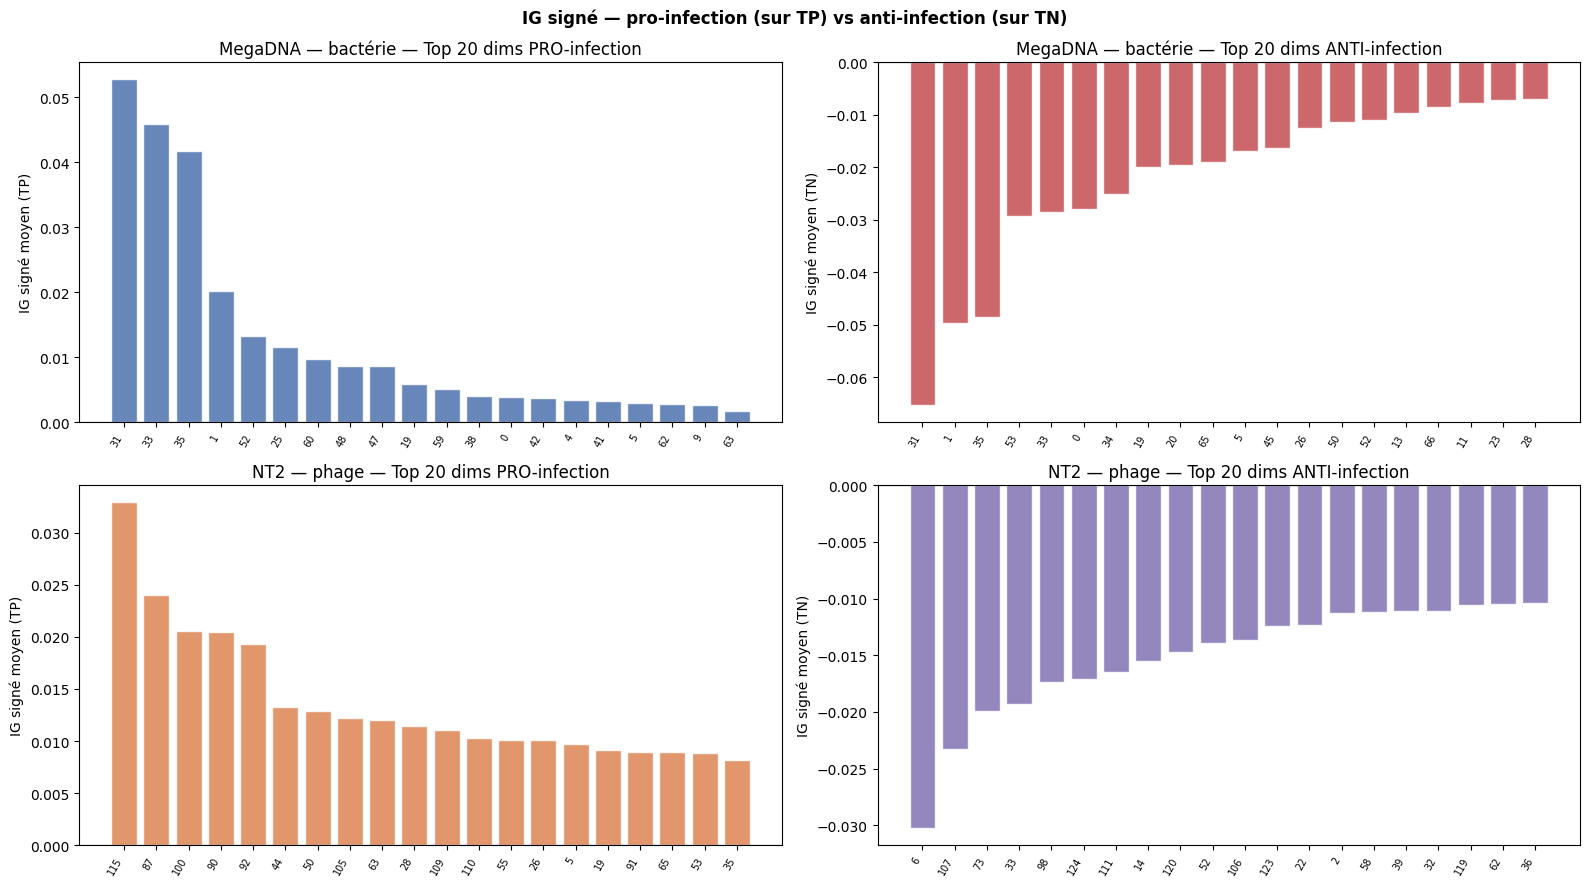

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for ax_row, (mean_push, mean_block, top_push, top_block, title, color_p, color_b) in enumerate([
    (mean_ig_bact_tp,  mean_ig_bact_tn,  top_bact_push,  top_bact_block,  "MegaDNA — bactérie", "#4C72B0", "#C44E52"),
    (mean_ig_phage_tp, mean_ig_phage_tn, top_phage_push, top_phage_block, "NT2 — phage",        "#DD8452", "#8172B3"),
]):
    # Pro-infection : IG signé moyen sur TP
    ax = axes[ax_row, 0]
    ax.bar(range(K), mean_push[top_push], color=color_p, alpha=0.85, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(range(K))
    ax.set_xticklabels([str(d) for d in top_push], rotation=60, ha="right", fontsize=7)
    ax.set_ylabel("IG signé moyen (TP)")
    ax.set_title(f"{title} — Top {K} dims PRO-infection")

    # Anti-infection : IG signé moyen sur TN
    ax = axes[ax_row, 1]
    ax.bar(range(K), mean_block[top_block], color=color_b, alpha=0.85, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(range(K))
    ax.set_xticklabels([str(d) for d in top_block], rotation=60, ha="right", fontsize=7)
    ax.set_ylabel("IG signé moyen (TN)")
    ax.set_title(f"{title} — Top {K} dims ANTI-infection")

plt.suptitle("IG signé — pro-infection (sur TP) vs anti-infection (sur TN)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

Dims bact  communes pro+anti : [0, 1, 5, 19, 31, 33, 35, 52]
Dims phage communes pro+anti : []

=== Bact dim 31 (orig 414) ===
  IG signé moyen TP : +0.0527
  IG signé moyen TN : -0.0653
  |IG| moyen        : 0.0896

  Valeur moyenne de la dim par outcome :
                      TP : -0.6881
                      TN : -0.3499
                      FP : -0.4154
                      FN : -0.7860
      baseline (médiane) : -0.7106


/tmp/ipykernel_30156/847542655.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=order, patch_artist=True, showfliers=False)


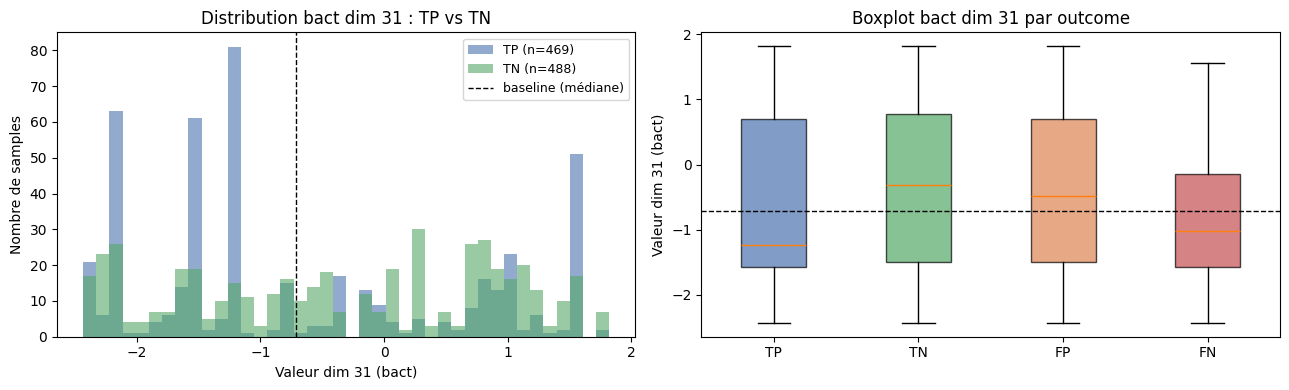

In [12]:
# Sanity check : les dims qui apparaissent dans les DEUX classements (pro & anti) sont les
# plus discriminatives. On regarde la VALEUR de la dim par outcome pour vérifier que
# c'est bien la valeur qui change entre TP et TN (et pas juste la sensibilité du modèle).

def dim_value_stats(side, dim):
    col = "bacterium_embedding" if side == "bact" else "phage_embedding"
    vals = np.array([e[dim].item() for e in dataset[col]])
    stats = {}
    for o in ["TP", "TN", "FP", "FN"]:
        mask = (dataset["outcome"] == o).values
        stats[o] = vals[mask].mean() if mask.sum() else float("nan")
    stats["baseline (médiane)"] = float(np.median(vals))
    return stats, vals


# Dims présentes dans les deux tops
common_bact  = sorted(set(top_bact_push.tolist())  & set(top_bact_block.tolist()))
common_phage = sorted(set(top_phage_push.tolist()) & set(top_phage_block.tolist()))
print(f"Dims bact  communes pro+anti : {common_bact}")
print(f"Dims phage communes pro+anti : {common_phage}\n")

# Focus dim 31 bact
DIM_FOCUS = 31
stats, vals = dim_value_stats("bact", DIM_FOCUS)
print(f"=== Bact dim {DIM_FOCUS} (orig {bact_dims_30[DIM_FOCUS]}) ===")
print(f"  IG signé moyen TP : {mean_ig_bact_tp[DIM_FOCUS]:+.4f}")
print(f"  IG signé moyen TN : {mean_ig_bact_tn[DIM_FOCUS]:+.4f}")
print(f"  |IG| moyen        : {mean_ig_bact_abs[DIM_FOCUS]:.4f}\n")
print("  Valeur moyenne de la dim par outcome :")
for k, v in stats.items():
    print(f"    {k:>20s} : {v:+.4f}")

# Distribution de la dim par outcome
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for o, color in [("TP", "#4C72B0"), ("TN", "#55A868")]:
    mask = (dataset["outcome"] == o).values
    ax.hist(vals[mask], bins=40, alpha=0.6, label=f"{o} (n={mask.sum()})", color=color)
ax.axvline(stats["baseline (médiane)"], color="black", ls="--", lw=1, label="baseline (médiane)")
ax.set_xlabel(f"Valeur dim {DIM_FOCUS} (bact)")
ax.set_ylabel("Nombre de samples")
ax.set_title(f"Distribution bact dim {DIM_FOCUS} : TP vs TN")
ax.legend(fontsize=9)

ax = axes[1]
order = ["TP", "TN", "FP", "FN"]
data_box = [vals[(dataset["outcome"] == o).values] for o in order]
bp = ax.boxplot(data_box, labels=order, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(stats["baseline (médiane)"], color="black", ls="--", lw=1)
ax.set_ylabel(f"Valeur dim {DIM_FOCUS} (bact)")
ax.set_title(f"Boxplot bact dim {DIM_FOCUS} par outcome")

plt.tight_layout()
plt.show()

## 5b. Explication locale par sample — waterfall IG

L'IG est intrinsèquement *local* : `ig_bact_raw[i]` / `ig_phage_raw[i]` donnent
la contribution signée de chaque dim *pour le sample i*. On visualise ça en
waterfall pour un sample représentatif de chaque outcome (TP / TN / FP / FN).

Choix du sample : par défaut, on prend celui dont la prédiction est **la plus
confiante** dans la catégorie (prob max pour TP/FP, prob min pour TN/FN) — c'est
là que la signature est la plus claire.

Samples sélectionnés (les plus confiants de chaque outcome) :
  TP : idx=1062  prob(inf)=0.996  bact=CP011301  phage=NC_005342
  TN : idx=483  prob(inf)=0.000  bact=CP013197  phage=NC_011166
  FP : idx=1158  prob(inf)=0.993  bact=CP011301  phage=NC_013691
  FN : idx=384  prob(inf)=0.000  bact=CP009257  phage=NC_030909


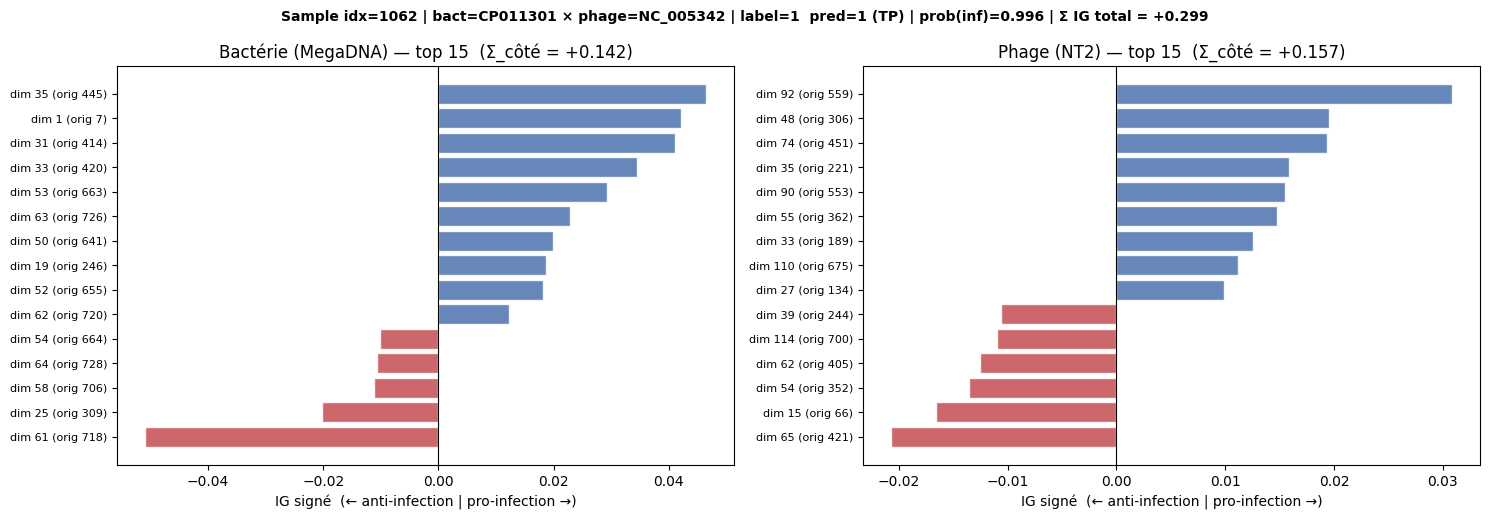

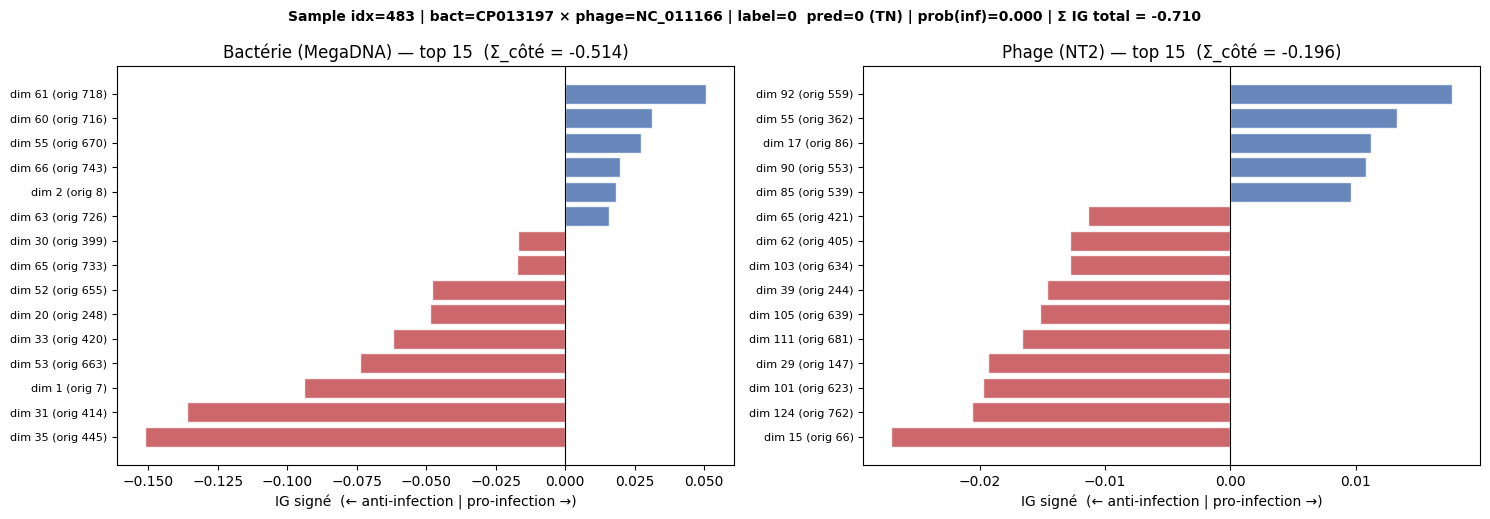

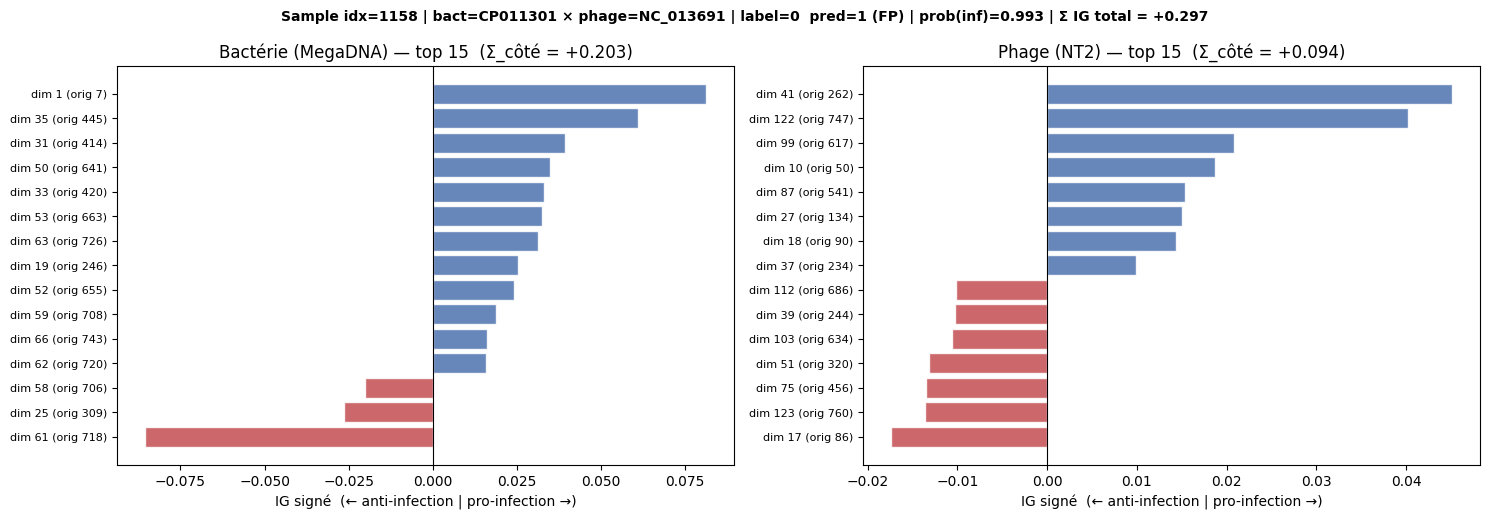

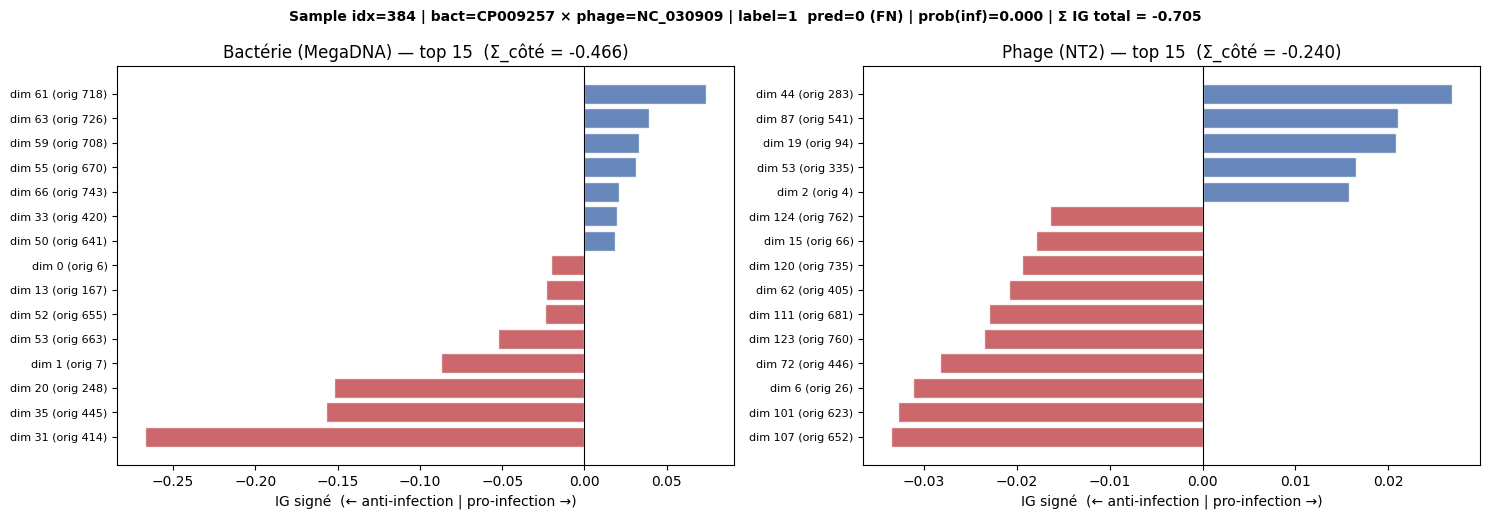

In [13]:
def plot_ig_waterfall(sample_idx, top_n=15):
    """Waterfall IG signé pour un sample : top-N dims par |IG|, signées et triées."""
    row  = dataset.iloc[sample_idx]
    ig_b = ig_bact_raw[sample_idx]
    ig_p = ig_phage_raw[sample_idx]

    # Top-N par |IG|, puis trié par valeur signée pour l'affichage
    top_b = np.argsort(np.abs(ig_b))[::-1][:top_n]
    top_p = np.argsort(np.abs(ig_p))[::-1][:top_n]
    top_b = top_b[np.argsort(ig_b[top_b])]
    top_p = top_p[np.argsort(ig_p[top_p])]

    fig, axes = plt.subplots(1, 2, figsize=(15, max(4, top_n * 0.35)))

    for ax, top, ig_arr, dims_orig, side_title in [
        (axes[0], top_b, ig_b, bact_dims_30,  "Bactérie (MegaDNA)"),
        (axes[1], top_p, ig_p, phage_dims_30, "Phage (NT2)"),
    ]:
        colors = ["#4C72B0" if v > 0 else "#C44E52" for v in ig_arr[top]]
        ax.barh(range(len(top)), ig_arr[top], color=colors, alpha=0.85, edgecolor="white")
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels([f"dim {d} (orig {dims_orig[d]})" for d in top], fontsize=8)
        ax.axvline(0, color="black", lw=0.8)
        ax.set_xlabel("IG signé  (← anti-infection | pro-infection →)")
        # somme côté pour info
        ax.set_title(f"{side_title} — top {top_n}  (Σ_côté = {ig_arr.sum():+.3f})")

    sum_ig = float(ig_b.sum() + ig_p.sum())
    fig.suptitle(
        f"Sample idx={sample_idx} | bact={row['bacterium_id']} × phage={row['phage_id']} | "
        f"label={int(row['interaction_type'])}  pred={int(row['prediction'])} ({row['outcome']}) | "
        f"prob(inf)={row['probability']:.3f} | Σ IG total = {sum_ig:+.3f}",
        fontsize=10, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


def pick_sample(outcome_label):
    """Sample le plus confiant de la catégorie : prob max (TP/FP) ou prob min (TN/FN)."""
    sub = dataset[dataset["outcome"] == outcome_label]
    if len(sub) == 0:
        return None
    if outcome_label in ("TP", "FP"):
        return int(sub["probability"].idxmax())
    return int(sub["probability"].idxmin())


print("Samples sélectionnés (les plus confiants de chaque outcome) :")
selected = {}
for o in ["TP", "TN", "FP", "FN"]:
    idx = pick_sample(o)
    selected[o] = idx
    if idx is not None:
        print(f"  {o} : idx={idx}  prob(inf)={dataset.iloc[idx]['probability']:.3f}  "
              f"bact={dataset.iloc[idx]['bacterium_id']}  phage={dataset.iloc[idx]['phage_id']}")

for o in ["TP", "TN", "FP", "FN"]:
    if selected[o] is not None:
        plot_ig_waterfall(selected[o], top_n=15)